****Season Agricultural Performance Analysis****

**Major Data Analytics Project**

**Domain**: Agriculture

**Project** Theme:Seasonal Agricultural performance

**Tools:** Pandas,Numpy,Matplotlib,Seaborn

**Project Goal:**
How does agricultural performance change across seasons, and what insights can help improve seasonal agricultural planning?*

**1.Problem Statement**

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

**2.Problem Objective**

1. Explore and understand the dataset.  
2. Clean and prepare the data for analysis.  
3. Examine how agricultural performance varies across seasons.  
4. Identify important seasonal patterns and trends.  
5. Investigate relationships between seasonal conditions and agricultural outcomes.  
6. Compare relevant groups within different seasons.  
7. Identify significant differences or unusual patterns.  
8. Apply appropriate statistical and visualization techniques.  
9. Interpret findings based on evidence from the dataset.  
10. Develop meaningful conclusions and data-driven recommendations.

**3.Dataset**
The dataset contains farm level agricultural records covering different seasons,locations crops,environmental conditions,farming practices,production,costs,revenue,profit anad resourse usage.

**Dataset file:** seasonal_agriculture_performance_dataset (3).csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/seasonal_agriculture_performance_dataset (3).csv')

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


Top 5 Rows Analysis:
The first five rows were examined to understand the structure of the agricultural dataset and the different attributes related to crops, seasons, environmental conditions, resource usage, production, and economic performance.

In [5]:
df.shape

(4000, 28)

In [6]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [10]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].median())

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(df["Yield_Tonnes_Ha"].median())

In [11]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [36]:
duplicate_count = df.duplicated().sum()
print("Duplicate records:", duplicate_count)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate records: 0
Shape after removing duplicates: (4000, 28)


## Univariate Analysis

Univariate analysis examines one variable at a time. In this project, the distribution of agricultural records across different seasons is analyzed using value counts and a count plot.

In [13]:
df["Season"].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


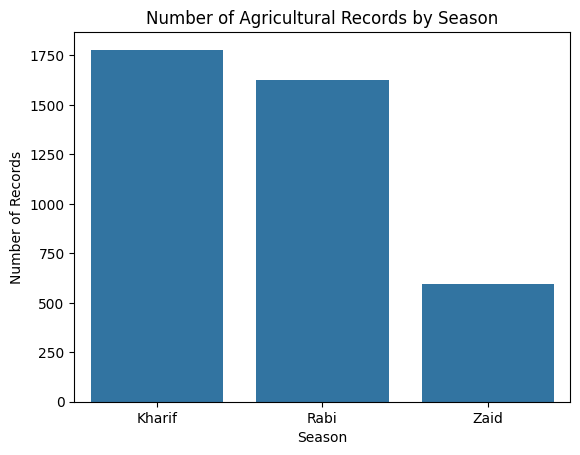

In [14]:
sns.countplot(x="Season", data=df)
plt.title("Number of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()

In [15]:
df.groupby("Season")["Yield_Tonnes_Ha"].mean()

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


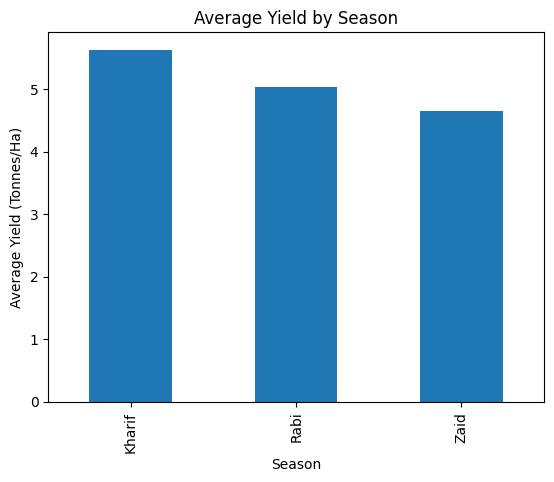

In [16]:
df.groupby("Season")["Yield_Tonnes_Ha"].mean().plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

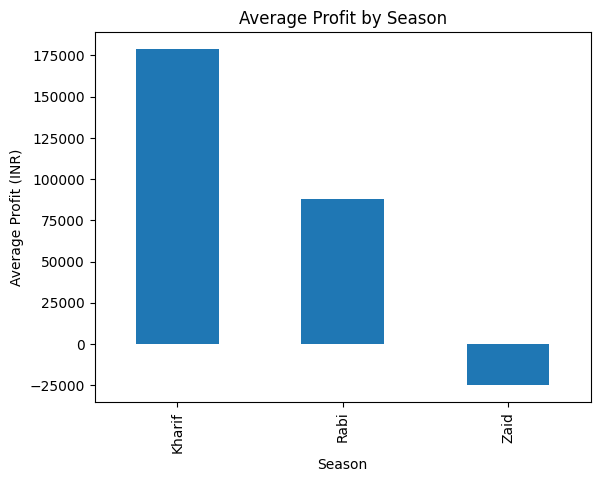

In [17]:
df.groupby("Season")["Profit_INR"].mean().plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()

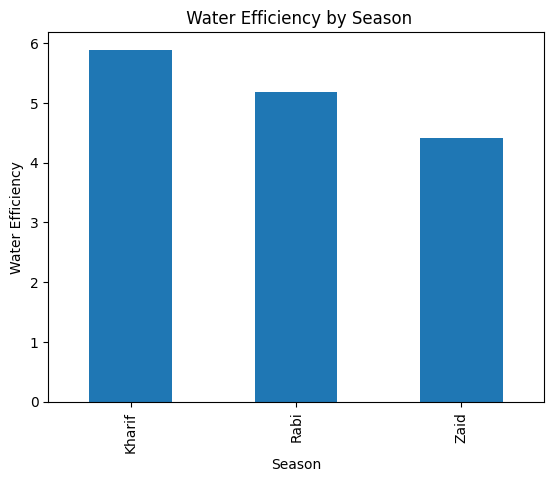

In [21]:
df.groupby("Season")["Water_Efficiency_t_per_1000m3"].mean().plot(kind="bar")

plt.title(" Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")
plt.show()

In [22]:
df.groupby("Season")[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct"
]].mean()

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.199663,28.454019,71.812591,6.793367,31.149859
Rabi,437.615366,23.489183,57.893178,7.589797,24.069392
Zaid,304.654714,31.042088,52.012121,8.178788,19.279630


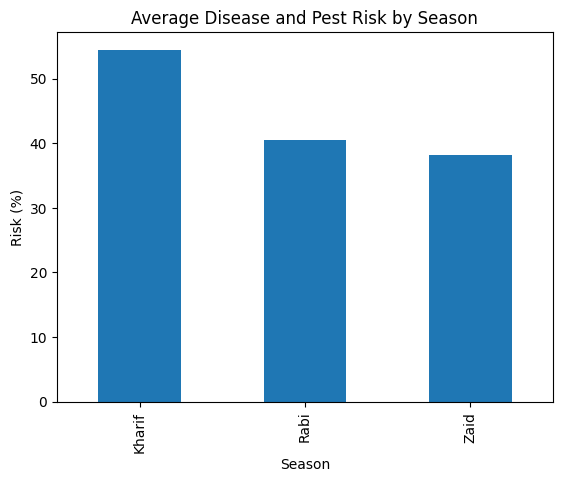

In [23]:
df.groupby("Season")["Disease_Pest_Risk_pct"].mean().plot(kind="bar")

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.show()

## Multivariate Analysis

This analysis examines crop, season, and yield together to understand how crop performance varies across different seasons.

In [26]:
crop_season = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


In [28]:
correlation = df.corr(numeric_only=True)

correlation

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007256,0.036870,0.000471,0.001821,0.009857,0.004033,0.013658,-0.006625,0.000195,...,0.015236,0.030203,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007256,1.000000,0.198492,0.521069,-0.362779,0.016657,0.508941,0.007460,0.020940,0.031373,...,-0.018581,0.030951,0.024447,0.000639,0.013041,0.098146,0.107648,0.002240,0.058102,0.621762
Avg_Temperature_C,0.036870,0.198492,1.000000,0.138136,-0.033863,0.029988,0.084001,0.018707,0.008508,0.022993,...,-0.031943,0.009996,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.521069,0.138136,1.000000,-0.297298,0.028447,0.446470,0.001198,-0.005963,-0.003070,...,-0.045598,0.012297,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.362779,-0.033863,-0.297298,1.000000,-0.017806,-0.302846,0.009920,0.001544,-0.014407,...,0.021257,-0.015341,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016657,0.029988,0.028447,-0.017806,1.000000,0.031183,0.006286,0.016620,-0.019407,...,-0.004181,-0.020672,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004033,0.508941,0.084001,0.446470,-0.302846,0.031183,1.000000,0.008884,0.013406,0.007796,...,-0.019556,0.010999,0.004787,0.016914,0.002741,0.079380,0.091281,0.003183,0.027776,0.375547
Nitrogen_kg_ha,0.013658,0.007460,0.018707,0.001198,0.009920,0.006286,0.008884,1.000000,0.010199,0.010490,...,0.014896,0.053149,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.020940,0.008508,-0.005963,0.001544,0.016620,0.013406,0.010199,1.000000,0.002847,...,-0.007575,0.047941,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031373,0.022993,-0.003070,-0.014407,-0.019407,0.007796,0.010490,0.002847,1.000000,...,0.006862,0.003382,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


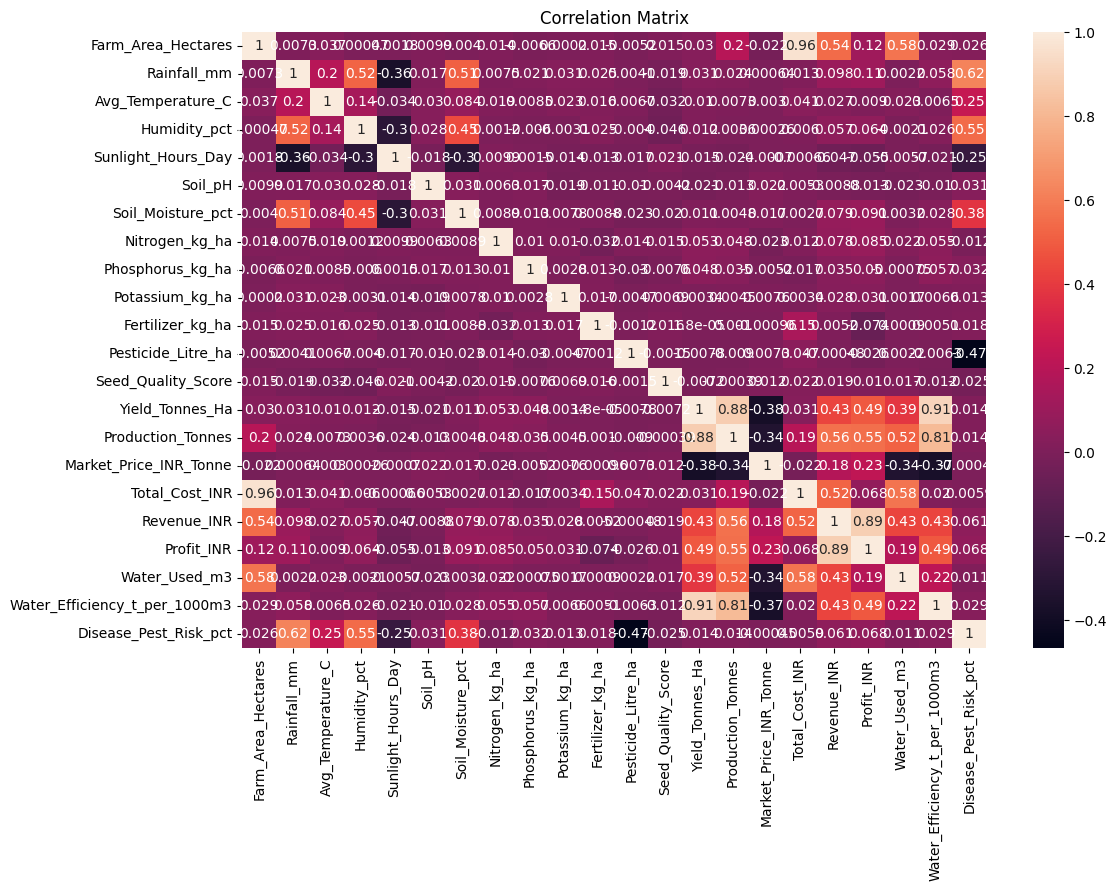

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(correlation, annot=True)

plt.title("Correlation Matrix")

plt.show()

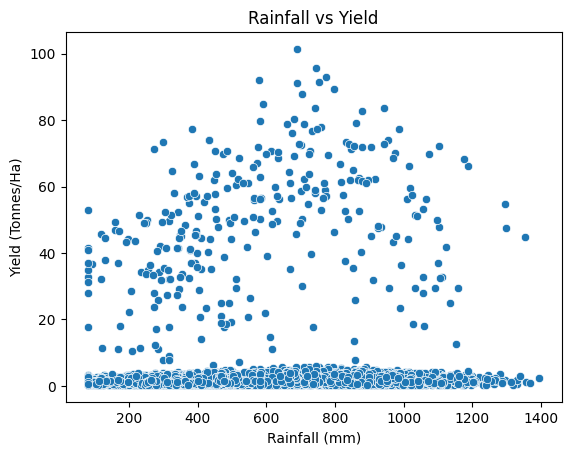

In [30]:
sns.scatterplot(
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    data=df
)

plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [31]:
# Outlier Investigation using Z-score

numeric_data = df.select_dtypes(include=np.number)

z_scores = (numeric_data - numeric_data.mean()) / numeric_data.std()

outliers = (z_scores.abs() >= 3)

outliers.sum()

,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,2
Humidity_pct,4
Sunlight_Hours_Day,11
Soil_pH,0
Soil_Moisture_pct,1
Nitrogen_kg_ha,7
Phosphorus_kg_ha,7
Potassium_kg_ha,4


In [32]:
outliers.sum().sort_values(ascending=False)

,0
Yield_Tonnes_Ha,170
Production_Tonnes,132
Water_Efficiency_t_per_1000m3,126
Profit_INR,106
Revenue_INR,97
Water_Used_m3,95
Sunlight_Hours_Day,11
Fertilizer_kg_ha,8
Phosphorus_kg_ha,7
Nitrogen_kg_ha,7


The Z-score method was used to identify unusually high or low numerical values. A Z-score of ±3 or beyond was considered an outlier. Outliers were investigated to understand unusual agricultural conditions, production values, or economic outcomes.

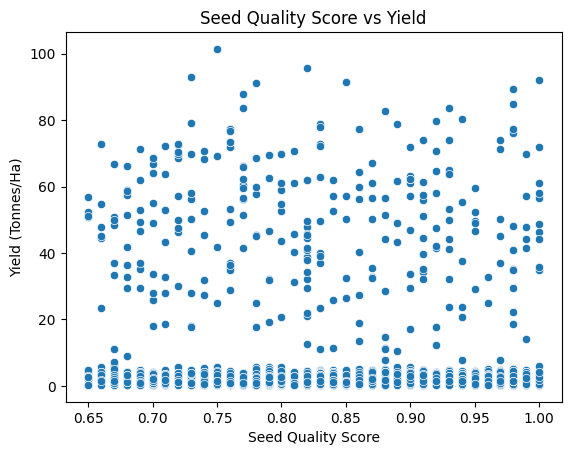

In [33]:
sns.scatterplot(
    x="Seed_Quality_Score",
    y="Yield_Tonnes_Ha",
    data=df
)

plt.title("Seed Quality Score vs Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

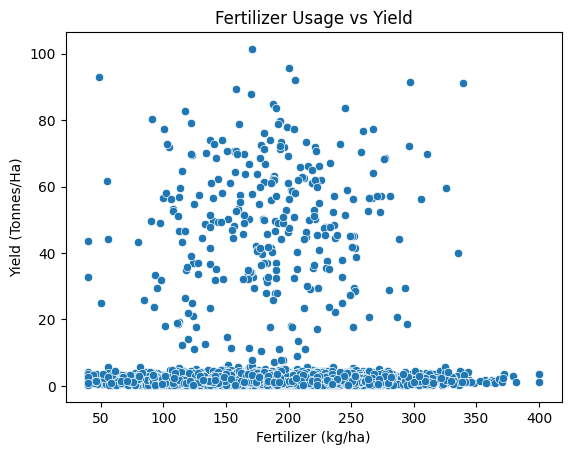

In [34]:
sns.scatterplot(
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    data=df
)

plt.title("Fertilizer Usage vs Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

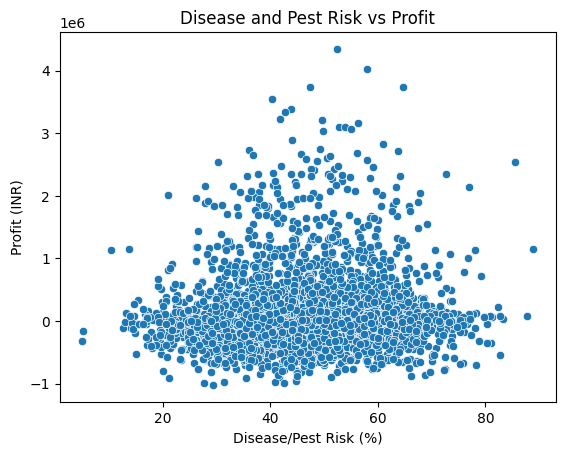

In [35]:
sns.scatterplot(
    x="Disease_Pest_Risk_pct",
    y="Profit_INR",
    data=df
)

plt.title("Disease and Pest Risk vs Profit")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Profit (INR)")
plt.show()

In [37]:
season_summary = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

season_summary

,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,
Kharif,5.63,178914.65,6102.20,5.89,54.47
Rabi,5.04,87689.47,5846.99,5.19,40.48
Zaid,4.64,-24804.82,6419.89,4.41,38.22


Insights:

Seasonal Yield: Kharif has the highest average yield, while Zaid has the lowest.

Seasonal Profit: Kharif is the most profitable season, while Zaid shows an average loss.

Water Efficiency: Kharif has the highest average water efficiency.

Water Usage: Zaid uses the most water on average.

Disease/Pest Risk: Kharif has the highest average disease/pest risk.

Crop Performance: Average yield differs across crops and seasons.

Seed Quality and Yield: Examine whether higher seed quality is associated with higher yield.

Fertilizer and Yield: Examine the relationship between fertilizer usage and yield.




**Evidence-Based Recommendations:**

1.Seasonal farming decisions should consider differences in yield and profit across seasons.

2.Efficient water management should be encouraged in seasons with higher water requirements.

3.Farmers should select crops based on their performance in different seasons.

4.Disease and pest monitoring should be increased during seasons with higher risk.

5.Seed quality should be considered when planning crop production.

6.Fertilizer usage should be managed appropriately based on crop requirements and observed yield patterns.

**Limitations**

The analysis is based only on the available dataset.

Some columns contained missing values, which were handled using median values.

Outliers were investigated using the Z-score method.

Correlation indicates association between variables and does not prove causation.

The dataset may not represent every agricultural region or farming condition.

The analysis describes the available data and may not predict future agricultural performance.

**Conclusion**

The analysis shows that agricultural performance varies across seasons, crops, environmental conditions, resource usage, and economic factors. Seasonal comparisons helped identify differences in yield, production, profit, water usage, water efficiency, and disease and pest risk. Bivariate, multivariate, and correlation analyses helped identify relationships among important agricultural variables. These findings can support better seasonal planning, crop selection, resource management, and agricultural decision-making.